In [10]:
import sys
sys.path.append("..")


In [11]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr, ttest_ind, chi2_contingency
from src.utils import numerical_cols, categorical_cols, target_reg, target_cls

### Loading dataset

In [12]:
df = pd.read_csv(r"C:\projects\ml-pipeline\data\processed\feature_engineered_df.csv", encoding= 'utf-8')
df.head()

,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,...,Brand,Month,Year,Quarter,Profit_loss,CTR,Conversion_rate,Lead_Rate,Revenue_per_lead,Cost_per_click
0,social media,college students,21.0,"whatsapp, youtube",57804.0,6156.0,3616.0,2355.0,1867515.0,208.725,...,nykaa,4,2025,2,Profit,0.106498,0.382554,0.587394,516.458794,0.033906
1,paid ads,tier 2 city customers,18.0,youtube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.830,...,nykaa,4,2025,2,Profit,0.036176,0.408612,0.593496,530.820396,0.054450
2,influencer,youth,23.0,"google, whatsapp, youtube",15536.0,2182.0,952.0,755.0,197055.0,90.600,...,nykaa,1,2025,1,Profit,0.140448,0.346013,0.436297,206.990546,0.041522
3,email,working women,18.0,"facebook, instagram, youtube",88114.0,8413.0,2231.0,947.0,376906.0,249.070,...,nykaa,6,2025,2,Profit,0.095479,0.112564,0.265185,168.940385,0.029605
4,paid ads,college students,10.0,"facebook, instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.600,...,nykaa,12,2024,4,Profit,0.038639,0.336094,0.550361,251.600000,0.061074


### Splitting columns

In [13]:
num_cols = df.select_dtypes(exclude=['object', 'datetime64[ns]']).columns
cat_cols = df.select_dtypes(include=['object']).columns

C:\Users\dell\AppData\Local\Temp\ipykernel_10632\694039121.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [14]:
print(num_cols)
print(len(num_cols))

Index(['Duration', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue',
       'Acquisition_Cost', 'Engagement_Score', 'Month', 'Year', 'Quarter',
       'CTR', 'Conversion_rate', 'Lead_Rate', 'Revenue_per_lead',
       'Cost_per_click'],
      dtype='str')
16


In [15]:
numerical_cols = [col for col in num_cols if col != 'Revenue']
print(numerical_cols)
print(len(numerical_cols))

['Duration', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Acquisition_Cost', 'Engagement_Score', 'Month', 'Year', 'Quarter', 'CTR', 'Conversion_rate', 'Lead_Rate', 'Revenue_per_lead', 'Cost_per_click']
15


In [16]:
print(cat_cols)
print(len(cat_cols))

Index(['Campaign_Type', 'Target_Audience', 'Channel_Used', 'Language',
       'Customer_Segment', 'Brand', 'Profit_loss'],
      dtype='str')
7


In [17]:
categorical_cols = [col for col in cat_cols if col != 'Profit_loss']
print(categorical_cols)
print(len(categorical_cols))

['Campaign_Type', 'Target_Audience', 'Channel_Used', 'Language', 'Customer_Segment', 'Brand']
6


### Feature Selection

#### Num vs Num

In [18]:
#Pearson correlation measures linear relationships, while Spearman 
# correlation measures monotonic relationships based on ranks. During feature selection,
#  some features showed weak Pearson correlation but strong Spearman correlation, 
# indicating non-linear associations with the target. Therefore, 
# I used Spearman correlation to better capture those relationships.

In [19]:
corr_features= []
alpha = 0.05

for col in numerical_cols:
    corr, p_value = spearmanr(df['Revenue'], df[col])
    print(f"Spearman Correlation between Revenue and {col}: {corr:.2f} (p-value: {p_value:.4f})")
    
    if abs(corr) > 0.3 and p_value < alpha:
        corr_features.append((col, corr, p_value))
print("Features with strong correlation to Revenue:", corr_features)

Spearman Correlation between Revenue and Duration: -0.00 (p-value: 0.1614)
Spearman Correlation between Revenue and Impressions: 0.54 (p-value: 0.0000)
Spearman Correlation between Revenue and Clicks: 0.76 (p-value: 0.0000)
Spearman Correlation between Revenue and Leads: 0.82 (p-value: 0.0000)
Spearman Correlation between Revenue and Conversions: 0.87 (p-value: 0.0000)
Spearman Correlation between Revenue and Acquisition_Cost: -0.75 (p-value: 0.0000)
Spearman Correlation between Revenue and Engagement_Score: 0.57 (p-value: 0.0000)
Spearman Correlation between Revenue and Month: -0.00 (p-value: 0.1866)
Spearman Correlation between Revenue and Year: 0.00 (p-value: 0.6543)
Spearman Correlation between Revenue and Quarter: -0.00 (p-value: 0.2001)
Spearman Correlation between Revenue and CTR: 0.47 (p-value: 0.0000)
Spearman Correlation between Revenue and Conversion_rate: 0.36 (p-value: 0.0000)
Spearman Correlation between Revenue and Lead_Rate: 0.27 (p-value: 0.0000)
Spearman Correlation b

In [20]:
corr_features = pd.DataFrame(corr_features, columns= [['Feature', 'Correlation', 'P-value']])
corr_features

,Feature,Correlation,P-value
0,Impressions,0.543830,0.0
1,Clicks,0.758843,0.0
2,Leads,0.819483,0.0
3,Conversions,0.865260,0.0
4,Acquisition_Cost,-0.754578,0.0
5,Engagement_Score,0.570507,0.0
6,CTR,0.473181,0.0
7,Conversion_rate,0.362579,0.0
8,Revenue_per_lead,0.483441,0.0
9,Cost_per_click,-0.816651,0.0


### Num vs Cat

In [21]:
ttest_features = []
alpha = 0.05
for col in numerical_cols:
    group = [df[df['Profit_loss'] ==cls][col] for cls in df['Profit_loss'].unique()]
    t_stat, p_value = ttest_ind(*group)
    print(f"T-test between Profit_loss and {col}: t_stat= {t_stat:.2f}, p_value={p_value:.4f}")

    if p_value < alpha:
        ttest_features.append((col, t_stat, p_value))
        print(f"{col} is significantly different between Profit_loss classes (p < {alpha})")
    else:
        print(f"{col} is NOT significantly different between Profit_loss classes (p >= {alpha})")
   
   

T-test between Profit_loss and Duration: t_stat= -0.07, p_value=0.9454
Duration is NOT significantly different between Profit_loss classes (p >= 0.05)
T-test between Profit_loss and Impressions: t_stat= 171.33, p_value=0.0000
Impressions is significantly different between Profit_loss classes (p < 0.05)
T-test between Profit_loss and Clicks: t_stat= 209.00, p_value=0.0000
Clicks is significantly different between Profit_loss classes (p < 0.05)
T-test between Profit_loss and Leads: t_stat= 205.21, p_value=0.0000
Leads is significantly different between Profit_loss classes (p < 0.05)
T-test between Profit_loss and Conversions: t_stat= 199.97, p_value=0.0000
Conversions is significantly different between Profit_loss classes (p < 0.05)
T-test between Profit_loss and Acquisition_Cost: t_stat= -294.82, p_value=0.0000
Acquisition_Cost is significantly different between Profit_loss classes (p < 0.05)
T-test between Profit_loss and Engagement_Score: t_stat= 166.89, p_value=0.0000
Engagement_Scor

In [22]:
ttest_features= pd.DataFrame(ttest_features, columns= [['Feature', 'T-statistic', 'P-value']])
ttest_features

,Feature,T-statistic,P-value
0,Impressions,171.333279,0.000000e+00
1,Clicks,209.004656,0.000000e+00
2,Leads,205.209109,0.000000e+00
3,Conversions,199.966109,0.000000e+00
4,Acquisition_Cost,-294.817640,0.000000e+00
5,Engagement_Score,166.892605,0.000000e+00
6,CTR,123.075745,0.000000e+00
7,Conversion_rate,57.636644,0.000000e+00
8,Lead_Rate,29.321834,1.654249e-188
9,Revenue_per_lead,63.638187,0.000000e+00


### Cat vs Cat

In [23]:
chi2_features = []
alpha = 0.05

for col in categorical_cols:
    contingency_table = pd.crosstab(df['Profit_loss'], df[col])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-squared test between Profit_loss and {col}: chi2= {chi2:.2f}, p_value={p_value:.4f}")

    if p_value < alpha:
        chi2_features.append((col, chi2, p_value))
        print(f"{col} is significantly associated with Profit_loss (p < {alpha})")
    else:
        print(f"{col} is NOT significantly associated with Profit_loss (p >= {alpha})")


Chi-squared test between Profit_loss and Campaign_Type: chi2= 11.03, p_value=0.0263
Campaign_Type is significantly associated with Profit_loss (p < 0.05)
Chi-squared test between Profit_loss and Target_Audience: chi2= 3.78, p_value=0.4359
Target_Audience is NOT significantly associated with Profit_loss (p >= 0.05)
Chi-squared test between Profit_loss and Channel_Used: chi2= 41.73, p_value=0.3957
Channel_Used is NOT significantly associated with Profit_loss (p >= 0.05)
Chi-squared test between Profit_loss and Language: chi2= 0.80, p_value=0.8494
Language is NOT significantly associated with Profit_loss (p >= 0.05)
Chi-squared test between Profit_loss and Customer_Segment: chi2= 1.18, p_value=0.8816
Customer_Segment is NOT significantly associated with Profit_loss (p >= 0.05)
Chi-squared test between Profit_loss and Brand: chi2= 6.01, p_value=0.0496
Brand is significantly associated with Profit_loss (p < 0.05)


In [24]:
chi2_features = pd.DataFrame(chi2_features, columns= ['Feature', 'Chi-squared', 'P-value'])
chi2_features

,Feature,Chi-squared,P-value
0,Campaign_Type,11.025500,0.026279
1,Brand,6.005695,0.049646


### Feature Importance

In [25]:
X = df.drop(['Profit_loss', 'Revenue'], axis = 1)
Y_reg = df[target_reg]
Y_cls = df['Profit_loss']

In [26]:
X_encoded = pd.get_dummies(X, drop_first= True)
X_encoded

,Duration,Impressions,Clicks,Leads,Conversions,Acquisition_Cost,Engagement_Score,Month,Year,Quarter,...,Channel_Used_youtube,Language_english,Language_hindi,Language_tamil,Customer_Segment_premium shoppers,Customer_Segment_tier 2 city customers,Customer_Segment_working women,Customer_Segment_youth,Brand_purplle,Brand_tira
0,21.0,57804.0,6156.0,3616.0,2355.0,208.725,20.98,4,2025,2,...,False,False,True,False,False,False,False,False,False,False
1,18.0,91801.0,3321.0,1971.0,1357.0,180.830,7.24,4,2025,2,...,True,False,True,False,False,False,False,False,False,False
2,23.0,15536.0,2182.0,952.0,755.0,90.600,25.03,1,2025,1,...,False,True,False,False,False,False,False,False,False,False
3,18.0,88114.0,8413.0,2231.0,947.0,249.070,13.15,6,2025,2,...,False,False,True,False,False,False,False,True,False,False
4,10.0,96871.0,3743.0,2060.0,1258.0,228.600,7.29,12,2024,4,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166660,11.0,55113.0,3799.0,1476.0,1099.0,213.210,10.70,11,2024,4,...,False,False,False,False,False,False,False,True,False,True
166661,20.0,54886.0,1578.0,634.0,775.0,436.240,4.66,8,2024,3,...,False,True,False,False,False,False,True,False,False,True
166662,13.0,97954.0,11480.0,4567.0,2144.0,78.770,18.57,4,2025,2,...,False,False,False,True,True,False,False,False,False,True
166663,22.0,11669.0,3908.0,122.0,44.0,208.725,5.35,7,2024,3,...,False,True,False,False,False,False,True,False,False,True


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
le= LabelEncoder()
y_encoded = le.fit_transform(Y_cls)

In [29]:
rf_cls = RandomForestClassifier(n_estimators=20, random_state=42)
rf_cls.fit(X_encoded, y_encoded)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [30]:
importance_df= pd.DataFrame({'Features': X_encoded.columns, 
                             'Importance': rf_cls.feature_importances_}).sort_values('Importance', ascending=False,ignore_index=True)
print(importance_df)

                                    Features  Importance
0                           Acquisition_Cost    0.233073
1                             Cost_per_click    0.152718
2                           Revenue_per_lead    0.108505
3                                      Leads    0.085196
4                                Conversions    0.085032
..                                       ...         ...
67  Channel_Used_facebook, whatsapp, youtube    0.000629
68    Channel_Used_email, instagram, youtube    0.000628
69       Channel_Used_email, google, youtube    0.000622
70          Channel_Used_instagram, whatsapp    0.000619
71   Channel_Used_email, instagram, whatsapp    0.000617

[72 rows x 2 columns]


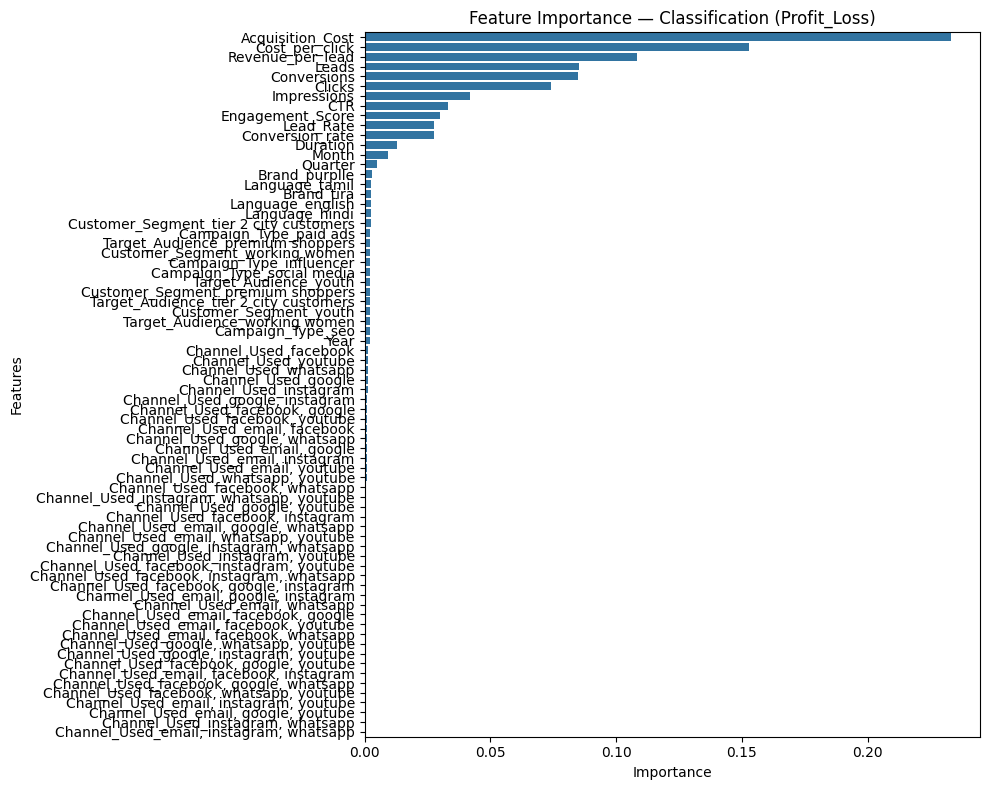

In [31]:
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Importance', y='Features')
plt.title('Feature Importance — Classification (Profit_Loss)')
plt.tight_layout()
plt.show()

In [32]:
weak_features= importance_df[importance_df['Importance'] < 0.01]
print("Weak features with less importance:", weak_features)


Weak features with less importance:                                       Features  Importance
12                                       Month    0.009465
13                                     Quarter    0.004829
14                               Brand_purplle    0.002787
15                              Language_tamil    0.002568
16                                  Brand_tira    0.002521
17                            Language_english    0.002452
18                              Language_hindi    0.002424
19      Customer_Segment_tier 2 city customers    0.002376
20                      Campaign_Type_paid ads    0.002374
21            Target_Audience_premium shoppers    0.002328
22              Customer_Segment_working women    0.002304
23                    Campaign_Type_influencer    0.002264
24                  Campaign_Type_social media    0.002256
25                       Target_Audience_youth    0.002232
26           Customer_Segment_premium shoppers    0.002218
27       Target_Audi

In [33]:
weak_features = pd.DataFrame(weak_features, columns= ['Features', 'Importance'])
weak_features

,Features,Importance
12,Month,0.009465
13,Quarter,0.004829
14,Brand_purplle,0.002787
15,Language_tamil,0.002568
16,Brand_tira,0.002521
17,Language_english,0.002452
18,Language_hindi,0.002424
19,Customer_Segment_tier 2 city customers,0.002376
20,Campaign_Type_paid ads,0.002374
21,Target_Audience_premium shoppers,0.002328


In [34]:
strong_features = importance_df[importance_df['Importance'] >= 0.01]
print("Strong features with importance >= 0.01:", strong_features)

Strong features with importance >= 0.01:             Features  Importance
0   Acquisition_Cost    0.233073
1     Cost_per_click    0.152718
2   Revenue_per_lead    0.108505
3              Leads    0.085196
4        Conversions    0.085032
5             Clicks    0.074135
6        Impressions    0.041752
7                CTR    0.033031
8   Engagement_Score    0.029937
9          Lead_Rate    0.027538
10   Conversion_rate    0.027533
11          Duration    0.012995


In [35]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
rf_reg = RandomForestRegressor(n_estimators=20, random_state=42)
rf_reg.fit(X_encoded, Y_reg)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [37]:
importance_df_reg = pd.DataFrame({
    'Feature'   : X_encoded.columns,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

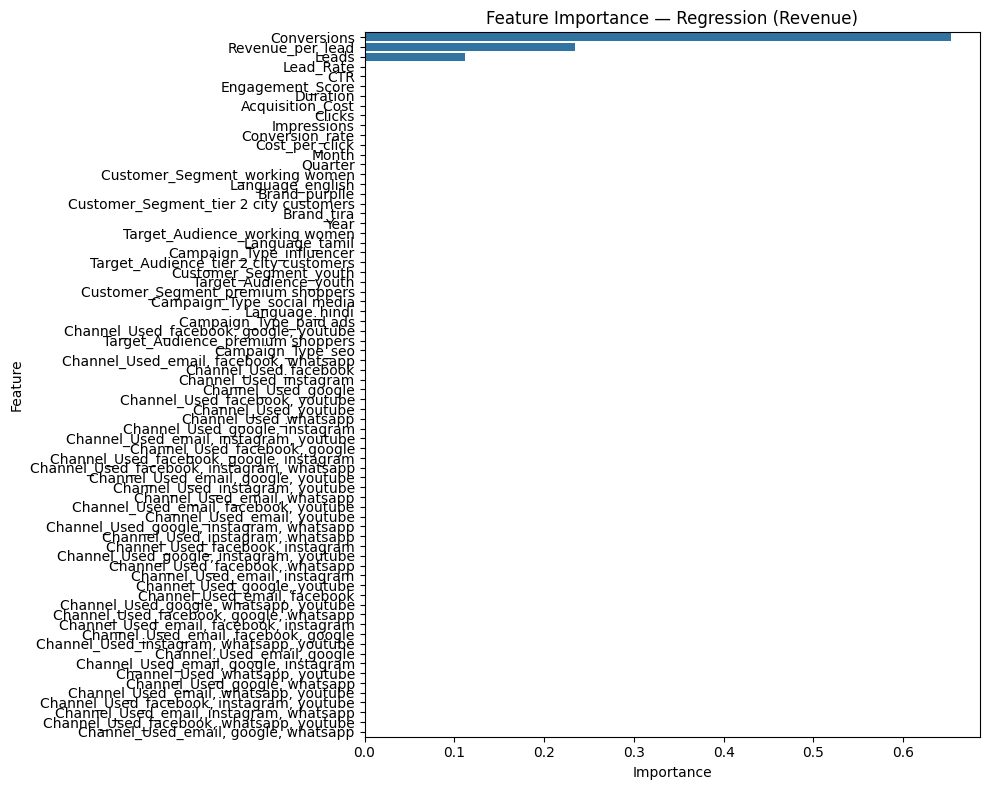

In [38]:
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df_reg, x='Importance', y='Feature')
plt.title('Feature Importance — Regression (Revenue)')
plt.tight_layout()
plt.show()

In [39]:
weak_features_reg = importance_df_reg[importance_df_reg['Importance'] < 0.01].sort_values('Importance', ascending=False, ignore_index=True)
print("Weak features with less importance:", weak_features_reg)

Weak features with less importance:                                       Feature    Importance
0                                   Lead_Rate  2.266513e-04
1                                         CTR  3.790025e-05
2                            Engagement_Score  3.466138e-05
3                                    Duration  3.201282e-05
4                            Acquisition_Cost  2.926869e-05
..                                        ...           ...
64      Channel_Used_email, whatsapp, youtube  3.213116e-07
65  Channel_Used_facebook, instagram, youtube  2.888328e-07
66    Channel_Used_email, instagram, whatsapp  2.783270e-07
67   Channel_Used_facebook, whatsapp, youtube  2.376676e-07
68       Channel_Used_email, google, whatsapp  2.342752e-07

[69 rows x 2 columns]


In [40]:
weak_features_reg = pd.DataFrame(weak_features_reg, columns= ['Feature', 'Importance'])
weak_features_reg

,Feature,Importance
0,Lead_Rate,2.266513e-04
1,CTR,3.790025e-05
2,Engagement_Score,3.466138e-05
3,Duration,3.201282e-05
4,Acquisition_Cost,2.926869e-05
...,...,...
64,"Channel_Used_email, whatsapp, youtube",3.213116e-07
65,"Channel_Used_facebook, instagram, youtube",2.888328e-07
66,"Channel_Used_email, instagram, whatsapp",2.783270e-07
67,"Channel_Used_facebook, whatsapp, youtube",2.376676e-07


In [41]:
strong_features_reg = importance_df_reg[importance_df_reg['Importance'] >= 0.01]
print("Strong features with importance >= 0.01:", strong_features_reg)

Strong features with importance >= 0.01:              Feature  Importance
4        Conversions    0.652934
13  Revenue_per_lead    0.234263
3              Leads    0.112208


### Variance inflation factor

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [43]:
X_num= numerical_cols
X_num

['Duration',
 'Impressions',
 'Clicks',
 'Leads',
 'Conversions',
 'Acquisition_Cost',
 'Engagement_Score',
 'Month',
 'Year',
 'Quarter',
 'CTR',
 'Conversion_rate',
 'Lead_Rate',
 'Revenue_per_lead',
 'Cost_per_click']

In [44]:
vif_df = pd.DataFrame()
vif_df['Features'] = X_num
vif_df['VIF'] = [variance_inflation_factor(X_encoded[X_num].values, i) for i in range(len(X_num))]
vif_df = vif_df.sort_values('VIF', ascending=False, ignore_index=True)
print(vif_df)


            Features         VIF
0            Quarter  115.388066
1               Year   90.244190
2              Month   85.767488
3             Clicks   46.861011
4                CTR   36.659550
5        Impressions   36.447597
6   Engagement_Score   31.267190
7              Leads   30.319807
8        Conversions   20.234992
9          Lead_Rate   12.186621
10   Conversion_rate   11.527351
11  Acquisition_Cost    7.904861
12          Duration    6.707741
13  Revenue_per_lead    4.682547
14    Cost_per_click    4.533906


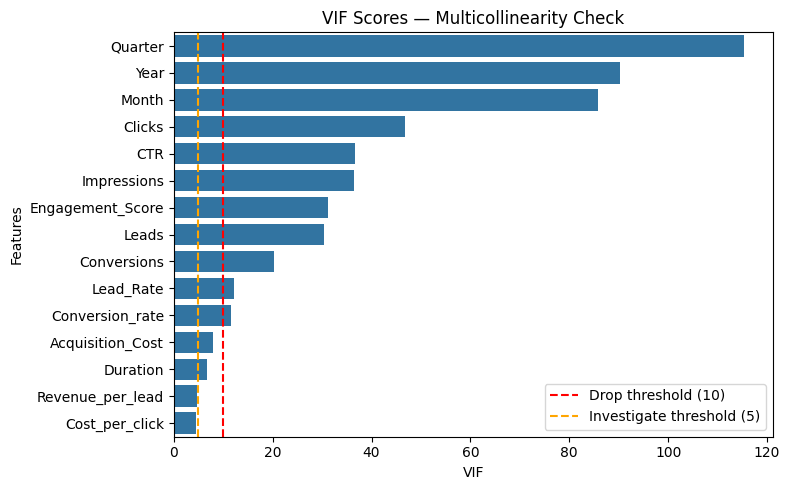

In [45]:
plt.figure(figsize=(8, 5))
sns.barplot(data=vif_df, x='VIF', y='Features')
plt.axvline(x=10, color='red',    linestyle='--', label='Drop threshold (10)')
plt.axvline(x=5,  color='orange', linestyle='--', label='Investigate threshold (5)')
plt.legend()
plt.title('VIF Scores — Multicollinearity Check')
plt.tight_layout()
plt.show()

In [46]:
vif_new_df = vif_df.drop([0,1,3,5,7,8], axis =0)
vif_new_df

,Features,VIF
2,Month,85.767488
4,CTR,36.659550
6,Engagement_Score,31.267190
9,Lead_Rate,12.186621
10,Conversion_rate,11.527351
11,Acquisition_Cost,7.904861
12,Duration,6.707741
13,Revenue_per_lead,4.682547
14,Cost_per_click,4.533906


In [47]:
cols_to_drop = ['Quarter', 'Year', 'Clicks','Impressions', 'Leads', 'Conversions']

In [48]:
X_num_clean =  df[numerical_cols].drop(cols_to_drop, axis=1)
X_num_clean

,Duration,Acquisition_Cost,Engagement_Score,Month,CTR,Conversion_rate,Lead_Rate,Revenue_per_lead,Cost_per_click
0,21.0,208.725,20.98,4,0.106498,0.382554,0.587394,516.458794,0.033906
1,18.0,180.830,7.24,4,0.036176,0.408612,0.593496,530.820396,0.054450
2,23.0,90.600,25.03,1,0.140448,0.346013,0.436297,206.990546,0.041522
3,18.0,249.070,13.15,6,0.095479,0.112564,0.265185,168.940385,0.029605
4,10.0,228.600,7.29,12,0.038639,0.336094,0.550361,251.600000,0.061074
...,...,...,...,...,...,...,...,...,...
166660,11.0,213.210,10.70,11,0.068931,0.289287,0.388523,308.256098,0.056123
166661,20.0,436.240,4.66,8,0.028751,0.491128,0.401774,215.321767,0.276451
166662,13.0,78.770,18.57,4,0.117198,0.186760,0.397822,97.646595,0.006861
166663,22.0,208.725,5.35,7,0.334904,0.011259,0.031218,220.360656,0.053410


In [49]:
vif_new_df = pd.DataFrame()
vif_new_df['Features'] = X_num_clean.columns
vif_new_df['VIF'] = [variance_inflation_factor(X_num_clean.values, i) for i in range(len(X_num_clean.columns))]
vif_new_df = vif_new_df.sort_values('VIF', ascending=False, ignore_index=True)
print(vif_new_df)

           Features        VIF
0  Engagement_Score  25.504027
1               CTR  19.770854
2         Lead_Rate   6.847456
3   Conversion_rate   6.655262
4          Duration   5.514434
5  Acquisition_Cost   5.367170
6             Month   3.964441
7    Cost_per_click   3.807774
8  Revenue_per_lead   3.791352


### Feature Voting

In [50]:
corr= ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost',
       'Engagement_Score','CTR','Conversion_rate','Revenue_per_lead','Cost_per_click']
ttest= ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost',
        'Engagement_Score','CTR','Conversion_rate','Lead_Rate','Revenue_per_lead','Cost_per_click']
chi2 = ['Campaign_Type','Brand']
feature_importance_cls = ['Acquisition_Cost','Cost_per_click','Conversions','Revenue_per_lead',
                          'Leads','Engagement_Score','Impressions','Clicks','CTR']
feature_importance_reg = ['Conversions','Revenue_per_lead','Leads']
VIF_features = ['Engagement_Score','CTR','Lead_Rate','Conversion_rate','Acquisition_Cost',
                'Duration','Revenue_per_lead','Cost_per_click','Month']


In [51]:
from collections import Counter

In [52]:
all_selected = corr + ttest + chi2 + feature_importance_cls + feature_importance_reg + VIF_features
vote_df = pd.DataFrame(Counter(all_selected).items(), columns=['Feature', 
                                        'Votes']).sort_values('Votes', ascending=False, ignore_index=True )
print(vote_df)


             Feature  Votes
0   Revenue_per_lead      5
1   Acquisition_Cost      4
2              Leads      4
3   Engagement_Score      4
4                CTR      4
5     Cost_per_click      4
6        Conversions      4
7        Impressions      3
8             Clicks      3
9    Conversion_rate      3
10         Lead_Rate      2
11     Campaign_Type      1
12             Brand      1
13          Duration      1
14             Month      1


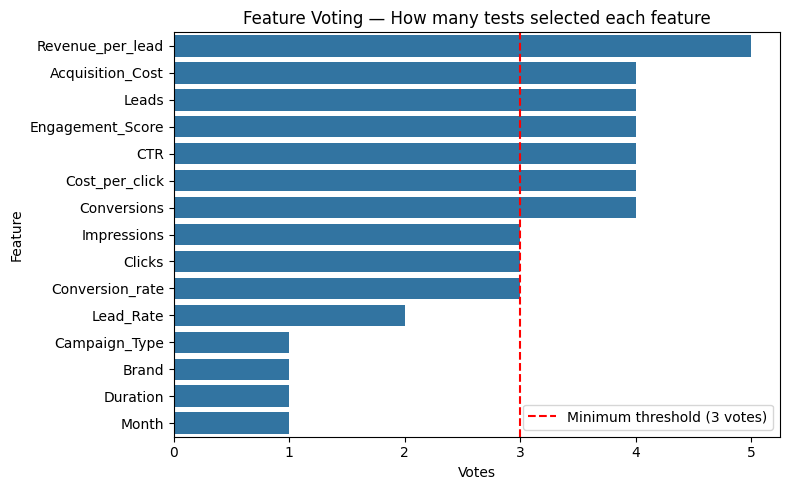

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(data=vote_df, x='Votes', y='Feature')
plt.axvline(x=3, color='red', linestyle='--', label='Minimum threshold (3 votes)')
plt.legend()
plt.title('Feature Voting — How many tests selected each feature')
plt.tight_layout()
plt.show()

#### sorting features based on votes

In [54]:
final_features = vote_df[vote_df['Votes']>=3]['Feature'].tolist()
final_features

['Revenue_per_lead',
 'Acquisition_Cost',
 'Leads',
 'Engagement_Score',
 'CTR',
 'Cost_per_click',
 'Conversions',
 'Impressions',
 'Clicks',
 'Conversion_rate']

In [55]:
X_check = df[final_features]

vif_final = pd.DataFrame()
vif_final['Feature'] = X_check.columns
vif_final['VIF']     = [variance_inflation_factor(X_check.values, i)
                        for i in range(X_check.shape[1])]

print(vif_final.sort_values('VIF', ascending=False))

            Feature        VIF
8            Clicks  38.316964
4               CTR  28.140589
3  Engagement_Score  27.865546
2             Leads  20.864603
6       Conversions  16.992395
7       Impressions  14.041577
9   Conversion_rate   8.710639
1  Acquisition_Cost   6.189819
0  Revenue_per_lead   4.389692
5    Cost_per_click   4.341802


#### Keeping features only with VIF score below 10 

In [56]:
# selected_features = numerical features that have passed the tests and have VIF < 10 and 
# categorical features that have passed the chi2 test and feature importance test.

In [58]:
selected_features = [' Cost_per_click', 'Acquisition_Cost', ' Conversion_rate'
                 'Campaign_Type', 'Channel_Used', 'Brand']
